In [2]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

GPU available: True
GPU name: Tesla T4


In [3]:
!git clone https://github.com/itz-deeptanshu/ExAI-project.git
%cd ExAI-project


Cloning into 'ExAI-project'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'ExAI-project'
/content


In [4]:
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_90f15c37018fb968f74d999b0ed75646"

In [5]:
!kaggle competitions download -c aptos2019-blindness-detection -p data/aptos

100% 9.51G/9.51G [00:59<00:00, 172MB/s]



In [6]:
!unzip -q data/aptos/aptos2019-blindness-detection.zip -d data/aptos

In [7]:
!ls data/aptos

aptos2019-blindness-detection.zip  test.csv	train.csv
sample_submission.csv		   test_images	train_images


In [8]:
import pandas as pd

df = pd.read_csv("data/aptos/train.csv")
print(df.head())
print(df.shape)

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
(3662, 2)


In [9]:
print(df['diagnosis'].value_counts().sort_index())
print()
print((df['diagnosis'].value_counts(normalize=True).sort_index() * 100).round(1))

diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

diagnosis
0    49.3
1    10.1
2    27.3
3     5.3
4     8.1
Name: proportion, dtype: float64


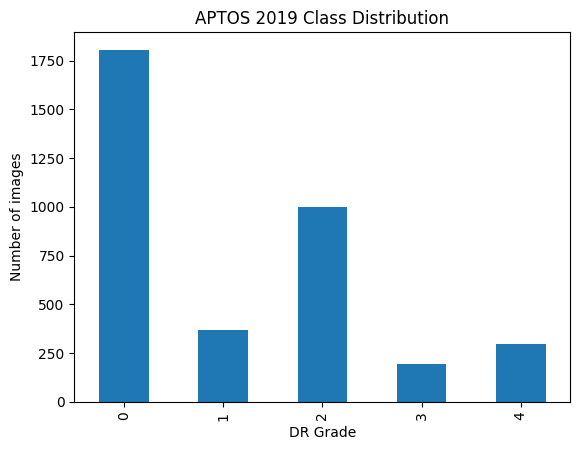

In [10]:
import matplotlib.pyplot as plt

df['diagnosis'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("DR Grade")
plt.ylabel("Number of images")
plt.title("APTOS 2019 Class Distribution")
plt.show()

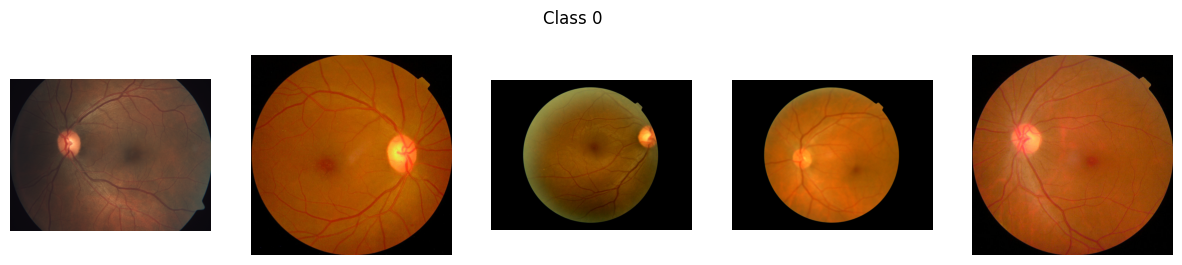

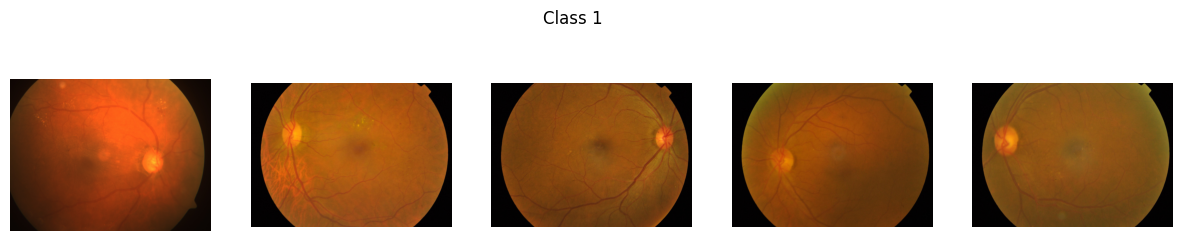

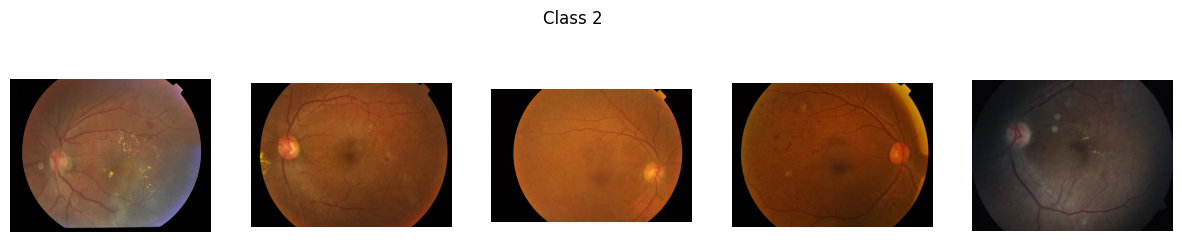

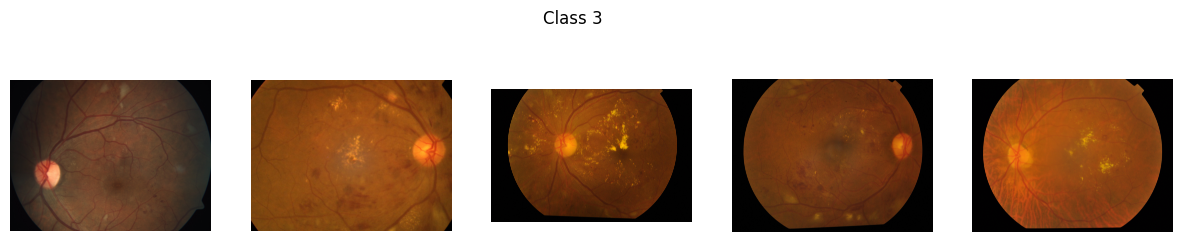

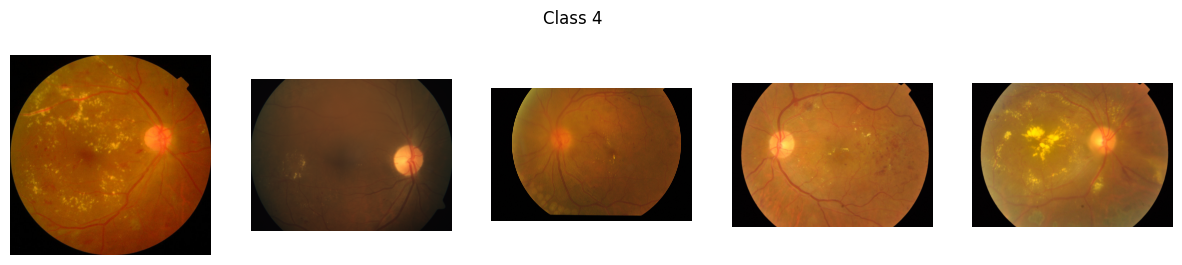

In [11]:
import cv2
import matplotlib.pyplot as plt

def show_samples(df, cls, n=5):
    samples = df[df['diagnosis'] == cls].sample(n, random_state=1)
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for ax, (_, row) in zip(axes, samples.iterrows()):
        path = f"data/aptos/train_images/{row['id_code']}.png"
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV loads as BGR, matplotlib wants RGB
        ax.imshow(img)
        ax.axis('off')
    plt.suptitle(f"Class {cls}")
    plt.show()

for c in range(5):
    show_samples(df, c)

In [12]:
import numpy as np

def crop_to_circle(img, tol=7):
    """Remove the black border around the circular fundus image."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = gray > tol
    if mask.sum() == 0:
        return img
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

def apply_clahe(img):
    """Improve contrast — fundus images often look washed out or uneven."""
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def preprocess_image(path, size=224):
    img = cv2.imread(path)
    img = crop_to_circle(img)
    img = apply_clahe(img)
    img = cv2.resize(img, (size, size))
    return img

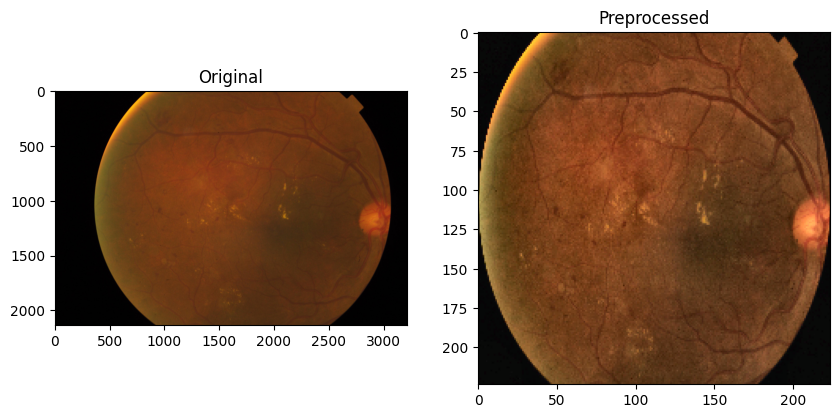

In [13]:
sample_path = f"data/aptos/train_images/{df['id_code'].iloc[0]}.png"
original = cv2.imread(sample_path)
processed = preprocess_image(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[1].imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
axes[1].set_title("Preprocessed")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df, test_size=0.15, stratify=df['diagnosis'], random_state=42
)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("\nTrain distribution:\n", train_df['diagnosis'].value_counts(normalize=True).sort_index().round(3))
print("\nVal distribution:\n", val_df['diagnosis'].value_counts(normalize=True).sort_index().round(3))

Train shape: (3112, 2)
Val shape: (550, 2)

Train distribution:
 diagnosis
0    0.493
1    0.101
2    0.273
3    0.053
4    0.081
Name: proportion, dtype: float64

Val distribution:
 diagnosis
0    0.493
1    0.102
2    0.273
3    0.053
4    0.080
Name: proportion, dtype: float64


In [15]:
train_df.to_csv("data/train_split.csv", index=False)
val_df.to_csv("data/val_split.csv", index=False)

In [19]:
mkdir -p src notebooks

In [20]:
%%writefile src/preprocessing.py
import cv2
import numpy as np

def crop_to_circle(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = gray > tol
    if mask.sum() == 0:
        return img
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def preprocess_image(path, size=224):
    img = cv2.imread(path)
    img = crop_to_circle(img)
    img = apply_clahe(img)
    img = cv2.resize(img, (size, size))
    return img

Writing src/preprocessing.py


In [21]:
!git config --global user.email "deeptanshuchakraborty@gmail.com"
!git config --global user.name "itz-deeptanshu"

In [22]:
!git add src/preprocessing.py data/train_split.csv data/val_split.csv
!git commit -m "Day 1: preprocessing function + stratified split"

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
